In [ ]:
#Laura Waldron
#Final Project

In [1]:
#1.Start the Spark session and load the dataset using PySpark. 
#Ensure that Spark is properly initialized before loading the data. You will need to do some exploratory analysis for the written report.

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FinalProjectNotebook") \
    .master("local[*]") \
    .getOrCreate()


In [3]:
#load the data using pyspark
import zipfile
import networkx as nx

zip_path = 'spotify_dataset.zip' #define the path of the file

with zipfile.ZipFile(zip_path, 'r') as zip_ref: #extract the files
    zip_ref.extractall('spotify_dataset')

nodes_df = spark.read.csv("spotify_dataset/nodes.csv", header=True, inferSchema=True)
edges_df = spark.read.csv("spotify_dataset/edges.csv", header=True, inferSchema=True)
nodes_df.show(10) #show the nodes file
edges_df.show(10) #show the edges file

+--------------------+------------------+---------+----------+--------------------+--------------------+
|          spotify_id|              name|followers|popularity|              genres|          chart_hits|
+--------------------+------------------+---------+----------+--------------------+--------------------+
|48WvrUGoijadXXCsG...|         Byklubben|   1738.0|      24.0|['nordic house', ...|          ['no (3)']|
|4lDiJcOJ2GLCK6p9q...|          Kontra K|1999676.0|      72.0|['christlicher ra...|['at (44)', 'de (...|
|652XIvIBNGg3C0KIG...|             Maxim|  34596.0|      36.0|                  []|          ['de (1)']|
|3dXC1YPbnQPsfHPVk...|Christopher Martin| 249233.0|      52.0|['dancehall', 'lo...|['at (1)', 'de (1)']|
|74terC9ol9zMo8rfz...|     Jakob Hellman|  21193.0|      39.0|['classic swedish...|          ['se (6)']|
|0FQMb3mVrAKlyU4H5...|              Madh|  26677.0|      19.0|                  []|          ['it (2)']|
|71BhXa24Zf5zcikUb...|             Juice|  11312.0|    

In [5]:
#print the schema of the dataset
edges_df.printSchema()
nodes_df.printSchema()

root
 |-- id_0: string (nullable = true)
 |-- id_1: string (nullable = true)

root
 |-- spotify_id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- followers: string (nullable = true)
 |-- popularity: double (nullable = true)
 |-- genres: string (nullable = true)
 |-- chart_hits: string (nullable = true)



In [13]:
#report average followers_count and popularity. 
#What is the distribution of these two areas?

from pyspark.sql.functions import expr, avg

#import some variables to assist. Try to cast the followers as a double variable
nodes_df_followers_popularity = nodes_df \
    .withColumn("followers", expr("try_cast(followers AS double)")) \
    .dropna(subset=["followers","popularity"])
#compute the averages
nodes_df_followers_popularity.select(
    avg("followers").alias("average_followers"),
    avg("popularity").alias("average popularity")
).show()
#show the distributions
nodes_df_followers_popularity.select("followers","popularity").describe().show()

+-----------------+------------------+
|average_followers|average popularity|
+-----------------+------------------+
|86224.26419762558| 21.15796236981914|
+-----------------+------------------+

+-------+-----------------+-----------------+
|summary|        followers|       popularity|
+-------+-----------------+-----------------+
|  count|           156417|           156417|
|   mean|86224.26419762558|21.15796236981914|
| stddev|940103.1061741839|18.33836180434846|
|    min|              0.0|              0.0|
|    max|     1.02156853E8|            100.0|
+-------+-----------------+-----------------+



In [5]:
#2. Construct the graph using networkX, where each node represents a user, and edges represent collaboration relationships.
import networkx as nx
#import pandas as pd
from pyspark.sql.functions import col
from pyspark.sql.functions import sum, when
#CHECK THIS TO MAKE SURE THE NULL COUNTING IS CORRECT
# # For edges_df
# missing_edges = edges_df.select([
#     sum(when(col(c).isNull(), 1).otherwise(0)).alias(f"{c}_missing")
#     for c in ["id_0", "id_1"]
# ])
# missing_edges.show()

# # For nodes_df
# missing_nodes = nodes_df.select([
#     sum(when(col(c).isNull(), 1).otherwise(0)).alias(f"{c}_missing")
#     for c in ["spotify_id", "name", "followers", "popularity", "genres", "chart_hits"]
# ])
# missing_nodes.show()

#drop the missing values for the networkx graph
edges_df_clean = edges_df.na.drop(subset=["id_0", "id_1"])
nodes_df_clean = nodes_df.na.drop(subset=["spotify_id"])
#convert both datasets into pandas dataframes
# edges_pd = edges_df_clean.select("id_0", "id_1").toPandas()
# nodes_pd = nodes_df_clean.select("spotify_id", "name", "followers", "popularity", "genres", "chart_hits").toPandas()

edges_spark = edges_df_clean.select("id_0", "id_1")
nodes_spark = nodes_df_clean.select(
    "spotify_id", "name", "followers", "popularity", "genres", "chart_hits"
)
nodes_list = nodes_spark.collect()
edges_list = edges_spark.collect()
G = nx.Graph() #create the networkx graph

for row in nodes_list:
    G.add_node(
        row["spotify_id"],
        name=row["name"],
        followers=row["followers"],
        popularity=row["popularity"],
        genres=row["genres"],
        chart_hits=row["chart_hits"]
    )
#add the edges
for row in edges_list:
    if row["id_0"] in G and row["id_1"] in G:
        G.add_edge(row["id_0"], row["id_1"])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph created with 156320 nodes and 300379 edges.


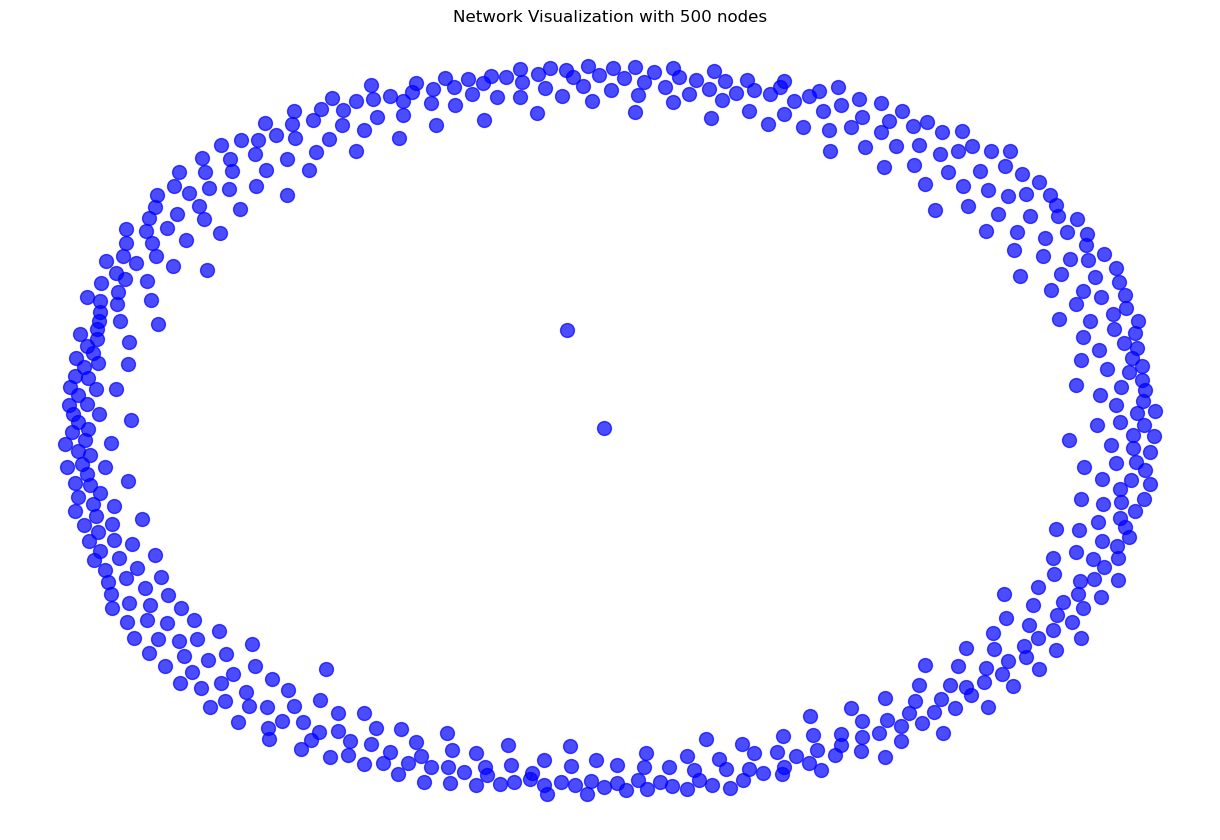

In [9]:
#3.Visualize the graph (or a small subset) using NetworkX's plotting functions to get an understanding of the network's structure.
#visualization with 500 nodes
import matplotlib.pyplot as plt
import random

#create a subset of the graph. Try multiple different sample sizes
#test that the subset is a representative of the bigger dataset.
#Do the above by showing degree distribution of the whole graph and also the subset graph
sample_nodes = random.sample(list(G.nodes), 500) #create a random subgraph with 500 nodes to visualize the network structure
subgraph = G.subgraph(sample_nodes)

plt.figure(figsize=(12, 8)) #create the figure
pos = nx.spring_layout(subgraph, seed=42)  # use the spring_layout
nx.draw( #draw the graph
    subgraph, pos,
    with_labels=False,
    node_color='blue',
    edge_color='red',
    node_size=100,
    alpha=0.7
)
plt.title("Network Visualization with 500 nodes")
plt.axis('off')
plt.show()

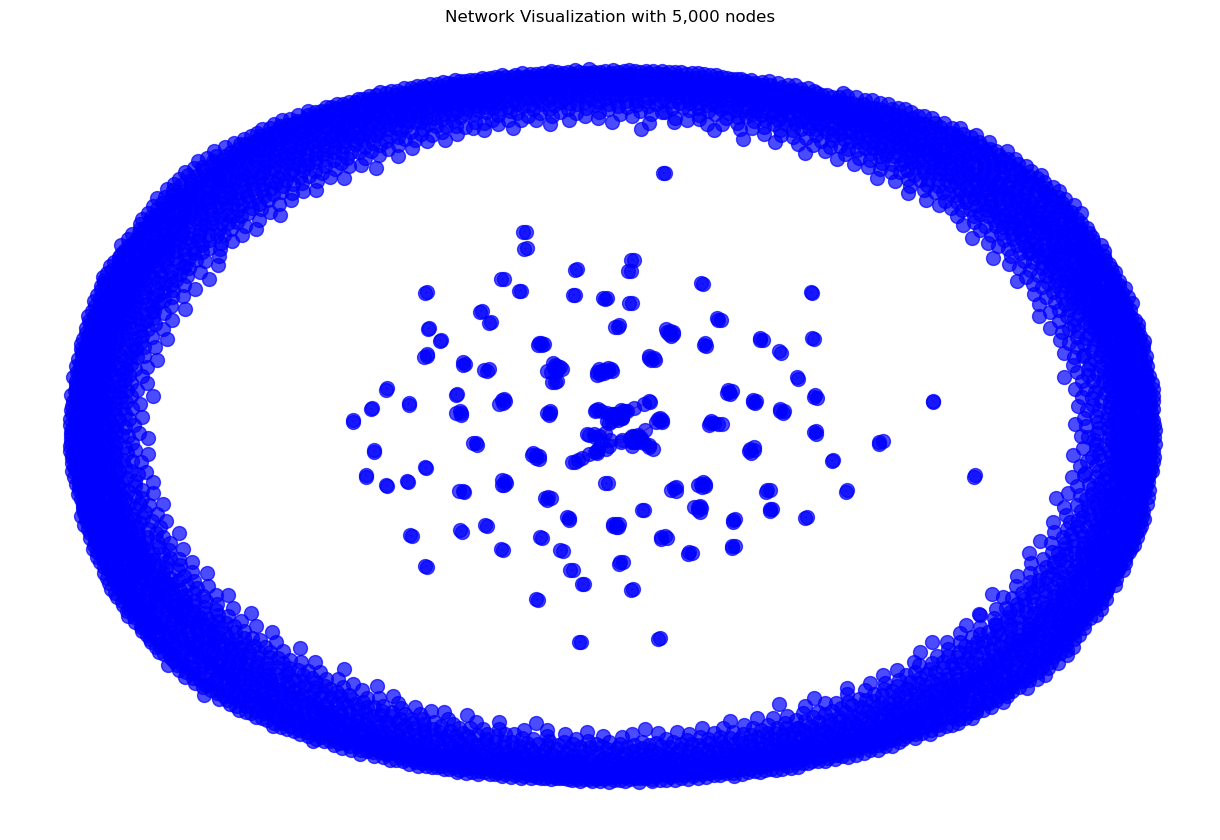

In [9]:
#3.Visualize the graph (or a small subset) using NetworkX's plotting functions to get an understanding of the network's structure.
import matplotlib.pyplot as plt
import random

#create a subset of the graph. Try multiple different sample sizes
#test that the subset is a representative of the bigger dataset.
#Do the above by showing degree distribution of the whole graph and also the subset graph
sample_nodes = random.sample(list(G.nodes), 5000) #create a random subgraph with 500 nodes to visualize the network structure
subgraph = G.subgraph(sample_nodes)

plt.figure(figsize=(12, 8)) #create the figure
pos = nx.spring_layout(subgraph, seed=42)  # use the spring_layout
nx.draw( #draw the graph
    subgraph, pos,
    with_labels=False,
    node_color='blue',
    edge_color='red',
    node_size=100,
    alpha=0.7
)
plt.title("Network Visualization with 5,000 nodes")
plt.axis('off')
plt.show()

In [ ]:
#visualize the entire graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=False,
    node_color='blue',
    edge_color='red',
    node_size=100,
    alpha=0.7
)
plt.title("Network Visualization of the Entire Graph")
plt.axis('off')
plt.show()
#THIS TAKES TOO LONG

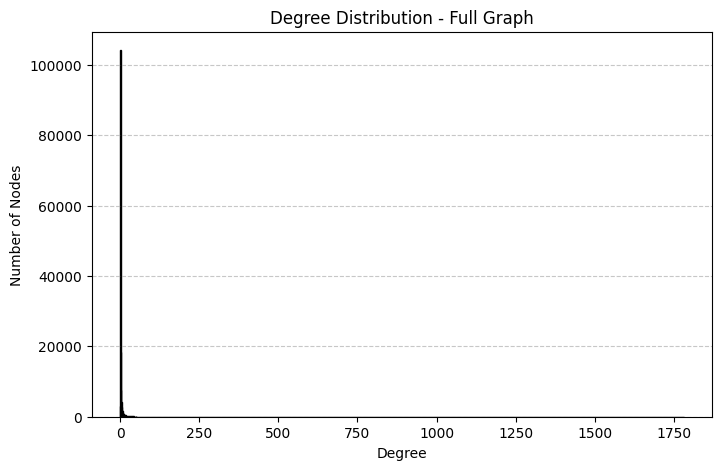

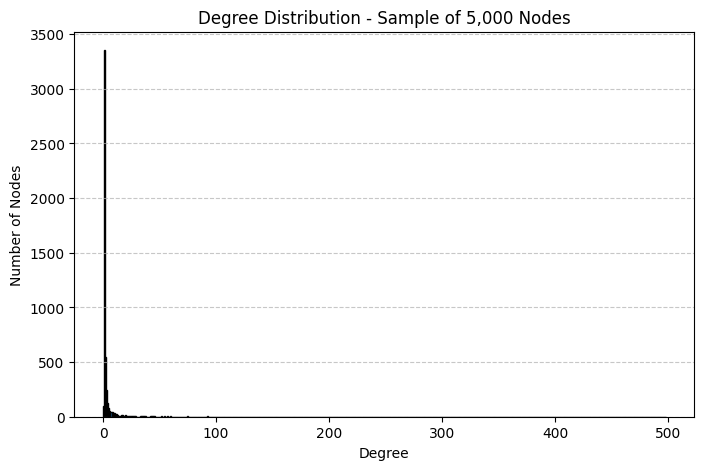

In [9]:
#3. Plot the degree distribution
#of the entire graph
import matplotlib.pyplot as plt
import random
degrees = [deg for node, deg in G.degree()]
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=range(min(degrees), max(degrees)+2), edgecolor='black', align='left')
plt.title("Degree Distribution - Full Graph")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#of a small sample
sample_nodes = random.sample(list(G.nodes()), min(5000, G.number_of_nodes()))
degrees_sample = [G.degree(n) for n in sample_nodes]

plt.figure(figsize=(8, 5))
plt.hist(degrees_sample, bins=range(min(degrees_sample), max(degrees_sample)+2), edgecolor='black', align='left')
plt.title("Degree Distribution - Sample of 5,000 Nodes")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
#4. For the report, you will also need network diameter, number of connected components, and edge density.

num_components = nx.number_connected_components(G) #number of connected components
print(f"Number of connected components: {num_components}")

Number of connected components: 4338


In [ ]:
#Network Diameter
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(G)) #calculate the shortest path lengths to find diameter
diameter = max(nx.eccentricity(G, sp=shortest_path_lengths).values()) 
print(f"Network Diameter: {diameter}") #print the network diameter
#The graph is too large to run this

In [11]:
print(len(G.edges()))#The nunmber of edges with connections in the entire graph


300379


In [13]:
edge_density = nx.density(G) #edge density
print(f"Edge density: {edge_density}")

Edge density: 2.458517184727294e-05


In [7]:
#Centrality Measures
import random
#subset_nodes = list(G.nodes())[:5000]
subset_nodes = random.sample(list(G.nodes), 5000) #create a random subgraph with 500 nodes to visualize the network structure


# Create a subgraph with these nodes
subgraph_5000 = G.subgraph(subset_nodes).copy()

degree_centrality = nx.centrality.degree_centrality(
    subgraph_5000
)  # save results in a variable to use again
(sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True))[:10]

[('0ksX396B3t2Gt8kwr0BJZk', 0.002400480096019204),
 ('6Mv8GjQa7LKUGCAqa9qqdb', 0.0016003200640128026),
 ('0FDJB5xf8i09jDjIg1qNED', 0.0014002800560112022),
 ('137W8MRPWKqSmrBGDBFSop', 0.001200240048009602),
 ('3ScY9CQxNLQei8Umvpx5g6', 0.001200240048009602),
 ('2dQgOfBP52UwjegY8FwJAY', 0.001200240048009602),
 ('65EXuYHVoehCKqp0kOS6px', 0.001200240048009602),
 ('20sxb77xiYeusSH8cVdatc', 0.0010002000400080016),
 ('0CbeG1224FS58EUx4tPevZ', 0.0010002000400080016),
 ('3gyp3OwaUX6NfBy1sHvY8b', 0.0010002000400080016)]

Text(0, 0.5, 'Counts')

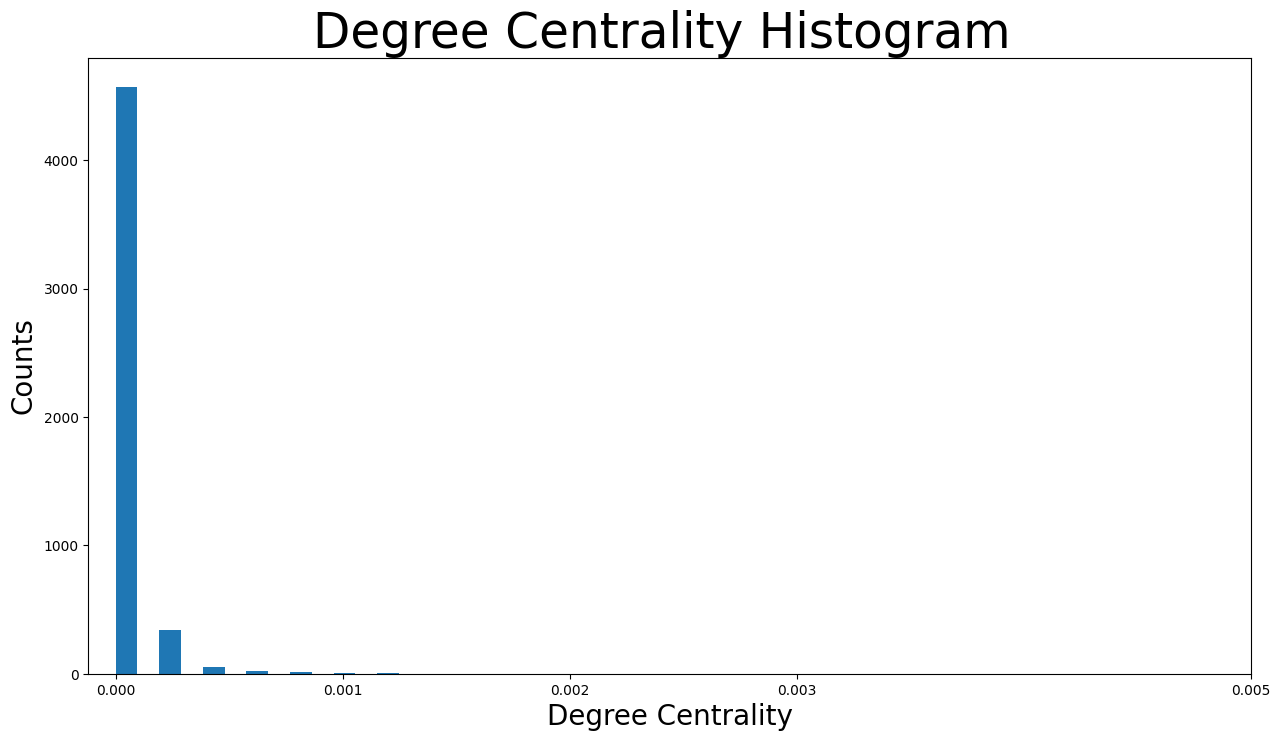

In [9]:
import matplotlib.pyplot as plt

# Degree Centrality Histogram
plt.figure(figsize=(15, 8))
plt.hist(degree_centrality.values(), bins=25)
plt.xticks(ticks=[0, 0.001, 0.002, 0.003, 0.005])  # set the x axis ticks
plt.title("Degree Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Degree Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

In [11]:
betweenness_centrality = nx.centrality.betweenness_centrality(
    subgraph_5000
)  # save results in a variable to use again
(sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True))[:10]

[('0ksX396B3t2Gt8kwr0BJZk', 1.2327395451079012e-05),
 ('0FDJB5xf8i09jDjIg1qNED', 1.1767059294211784e-05),
 ('4nXXIxTneJksvGXrlmX8oA', 1.1206723137344556e-05),
 ('5RiGhrEoM1SBjZoY25lCfe', 1.0966579070115744e-05),
 ('6eUKZXaKkcviH0Ku9w2n3V', 8.725234442646833e-06),
 ('20sxb77xiYeusSH8cVdatc', 6.7240338824067336e-06),
 ('0CbeG1224FS58EUx4tPevZ', 6.24374574794911e-06),
 ('7F2utINZ6tSokSiZTQBE27', 6.24374574794911e-06),
 ('0aKXalHKVzkLJ6aeUY3HMf', 6.163697725539506e-06),
 ('2dQgOfBP52UwjegY8FwJAY', 5.203121456624258e-06)]

Text(0, 0.5, 'Counts')

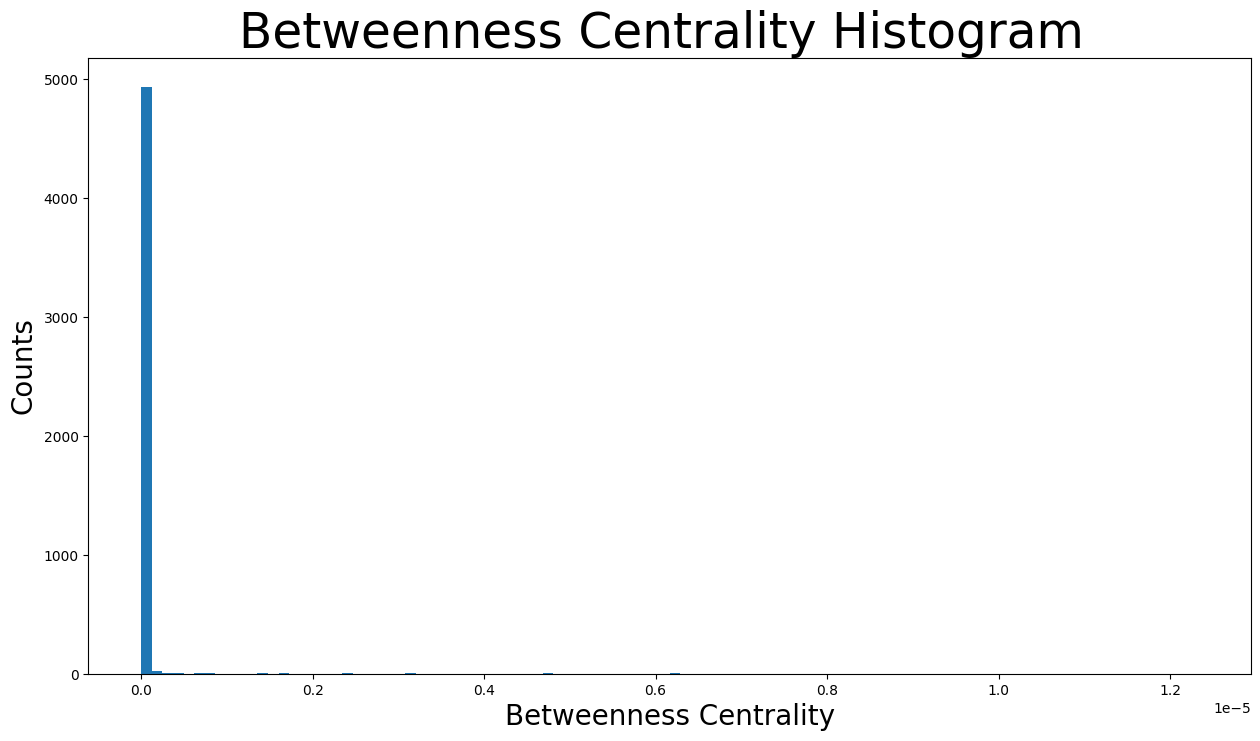

In [13]:
# Betweenness Centrality Histogram
plt.figure(figsize=(15, 8))
plt.hist(betweenness_centrality.values(), bins=100)
#plt.xticks(ticks=[0, 0.1, 0.3, 0.5, 1])  # set the x axis ticks
plt.title("Betweenness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Betweenness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

In [15]:
closeness_centrality = nx.centrality.closeness_centrality(
    subgraph_5000
)  # save results in a variable to use again
(sorted(closeness_centrality.items(), key=lambda item: item[1], reverse=True))[:10]

[('0ksX396B3t2Gt8kwr0BJZk', 0.0023534118588423567),
 ('6eUKZXaKkcviH0Ku9w2n3V', 0.002162594681098382),
 ('4nXXIxTneJksvGXrlmX8oA', 0.0018619108437072029),
 ('5RiGhrEoM1SBjZoY25lCfe', 0.0017603520704140827),
 ('0FDJB5xf8i09jDjIg1qNED', 0.0017603520704140827),
 ('20sxb77xiYeusSH8cVdatc', 0.0017394783304486984),
 ('6Mv8GjQa7LKUGCAqa9qqdb', 0.0016136560645462423),
 ('0aKXalHKVzkLJ6aeUY3HMf', 0.0015518255166184752),
 ('2jtiSAQnSSehAug5teBHwm', 0.0015097359094460403),
 ('6rUaup29ZGso2FeobZMNA3', 0.0015097359094460403)]

Text(0, 0.5, 'Counts')

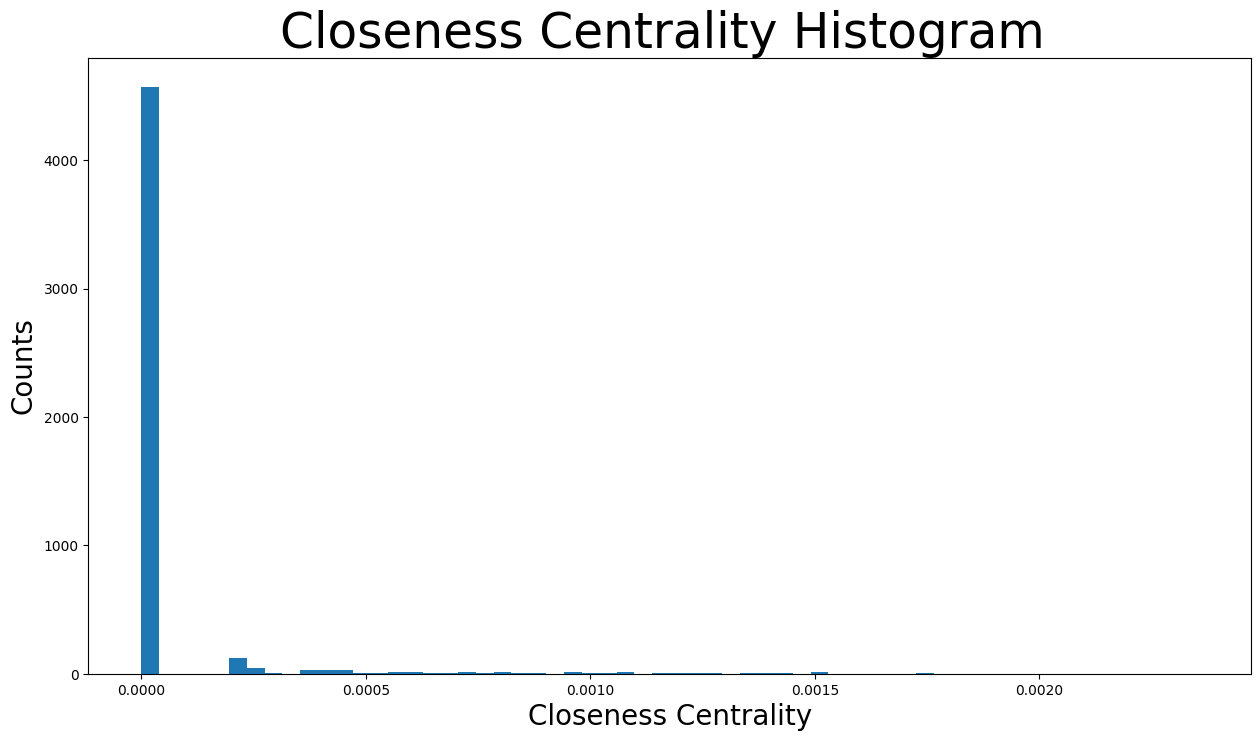

In [17]:
# Closeness Centrality Histogram
plt.figure(figsize=(15, 8))
plt.hist(closeness_centrality.values(), bins=60)
plt.title("Closeness Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Closeness Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

In [19]:
eigenvector_centrality = nx.centrality.eigenvector_centrality(
    subgraph_5000, max_iter=1000, tol=1e-06
)  # save results in a variable to use again
(sorted(eigenvector_centrality.items(), key=lambda item: item[1], reverse=True))[:10]

[('0ksX396B3t2Gt8kwr0BJZk', 0.6888856692897696),
 ('6eUKZXaKkcviH0Ku9w2n3V', 0.2724788772535543),
 ('2jtiSAQnSSehAug5teBHwm', 0.1956903469614334),
 ('6rUaup29ZGso2FeobZMNA3', 0.1956903469614334),
 ('5VTf3d6zLIJhNEaCcs9i9w', 0.1956903469614334),
 ('4greawD4iPVecLHKENer73', 0.1956903469614334),
 ('3kBTda7vNOOAA2Tu5uD13Y', 0.1956903469614334),
 ('7uyql7QaJZdpubTRISfvbK', 0.1956903469614334),
 ('0HjgS1pbPhuNrlPkda9INO', 0.1956903469614334),
 ('3E9T01xr1C6waIXZKe1vju', 0.1956903469614334)]

Text(0, 0.5, 'Counts')

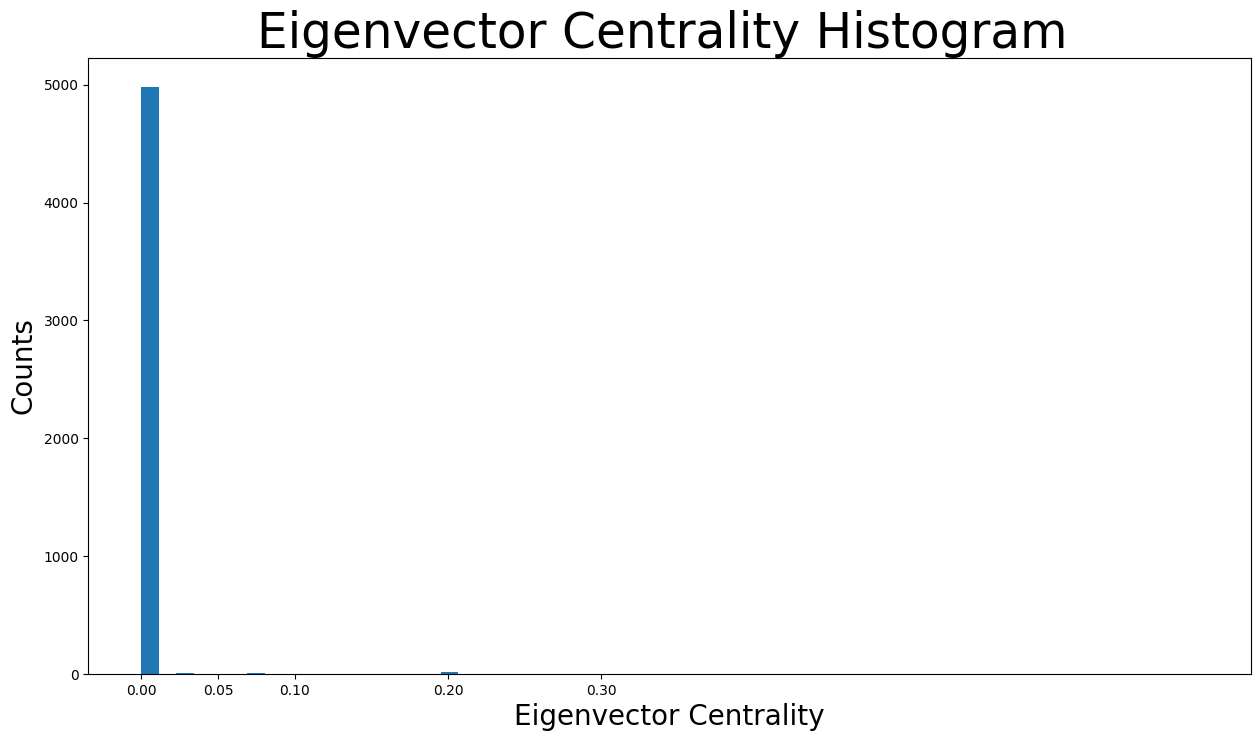

In [21]:
# Eigenvector Centrality Histogram
plt.figure(figsize=(15, 8))
plt.hist(eigenvector_centrality.values(), bins=60)
plt.xticks(ticks=[0, 0.05, 0.1, 0.2, 0.3])  # set the x axis ticks
plt.title("Eigenvector Centrality Histogram ", fontdict={"size": 35}, loc="center")
plt.xlabel("Eigenvector Centrality", fontdict={"size": 20})
plt.ylabel("Counts", fontdict={"size": 20})

In [23]:
#compute the page rank
pagerank_scores = nx.pagerank(subgraph_5000)

# Step 4: Sort and print the top 10 nodes by PageRank
top_10_pagerank = sorted(pagerank_scores.items(), key=lambda item: item[1], reverse=True)[:10]

print("Top 10 nodes by PageRank (subset of 5,000 nodes):")
for node, score in top_10_pagerank:
    print(f"Node: {node}, PageRank: {score:.6f}")

Top 10 nodes by PageRank (subset of 5,000 nodes):
Node: 0ksX396B3t2Gt8kwr0BJZk, PageRank: 0.005142
Node: 6Mv8GjQa7LKUGCAqa9qqdb, PageRank: 0.003529
Node: 0FDJB5xf8i09jDjIg1qNED, PageRank: 0.002934
Node: 3ScY9CQxNLQei8Umvpx5g6, PageRank: 0.002918
Node: 65EXuYHVoehCKqp0kOS6px, PageRank: 0.002741
Node: 2dQgOfBP52UwjegY8FwJAY, PageRank: 0.002668
Node: 137W8MRPWKqSmrBGDBFSop, PageRank: 0.002646
Node: 0xbdsXms9xTAtNmROodyy8, PageRank: 0.002510
Node: 2cy1zPcrFcXAJTP0APWewL, PageRank: 0.002510
Node: 2q9wk5fkeU2C9CgCKdh4AN, PageRank: 0.002325


In [44]:
#top 5 influential artists for each centrality measure

# id_to_name = dict(zip(nodes_spark["spotify_id"], nodes_spark["name"]))
id_to_name = {row["spotify_id"]: row["name"] for row in nodes_list}
def print_top_artists(centrality_dict, label, top_n=5):
    print(f"\nTop {top_n} Artists by {label} Centrality:")
    top_items = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]
    for node_id, score in top_items:
        name = id_to_name.get(node_id, "Unknown")
        print(f"Artist: {name}, Centrality Score: {score:.6f}")

print_top_artists(degree_centrality, "Degree")
print_top_artists(betweenness_centrality, "Betweeness")
print_top_artists(closeness_centrality, "Closeness")
print_top_artists(eigenvector_centrality, "Eigenvector")
print_top_artists(pagerank_scores, "PageRank")



Top 5 Artists by Degree Centrality:
Artist: A.R. Rahman, Centrality Score: 0.002601
Artist: INNA, Centrality Score: 0.002200
Artist: Coolio, Centrality Score: 0.001800
Artist: Sak Noel, Centrality Score: 0.001800
Artist: Rico Bernasconi, Centrality Score: 0.001600

Top 5 Artists by Betweeness Centrality:
Artist: Sak Noel, Centrality Score: 0.000088
Artist: INNA, Centrality Score: 0.000053
Artist: Rico Bernasconi, Centrality Score: 0.000045
Artist: Good Times Ahead, Centrality Score: 0.000033
Artist: KSHMR, Centrality Score: 0.000027

Top 5 Artists by Closeness Centrality:
Artist: Sak Noel, Centrality Score: 0.004390
Artist: INNA, Centrality Score: 0.003746
Artist: Rico Bernasconi, Centrality Score: 0.003649
Artist: Good Times Ahead, Centrality Score: 0.003469
Artist: KSHMR, Centrality Score: 0.003385

Top 5 Artists by Eigenvector Centrality:
Artist: Rico Bernasconi, Centrality Score: 0.422961
Artist: Sak Noel, Centrality Score: 0.416321
Artist: Coolio, Centrality Score: 0.363220
Artis

In [9]:
#calculate and discuss the average degree of the nodes. Sparse or Dense network?
#SPARSE NETWORK!!
#find the total number of nodes
num_nodes = G.number_of_nodes()

#find the total number of edges
num_edges = G.number_of_edges()

#calculate average degree: (2 * number of edges) / number of nodes
average_degree = (2 * num_edges) / num_nodes

print(f"Average Degree: {average_degree:.2f}")


Average Degree: 3.84


In [25]:

from pyspark.sql import Row
from pyspark.sql.functions import col
from pyspark.sql.functions import expr

#convert each centrality dictionary to a PySpark DataFrame
degree_df = spark.createDataFrame([Row(spotify_id=k, degree_centrality=v) for k, v in degree_centrality.items()])
betweenness_df = spark.createDataFrame([Row(spotify_id=k, betweenness_centrality=v) for k, v in betweenness_centrality.items()])
closeness_df = spark.createDataFrame([Row(spotify_id=k, closeness_centrality=v) for k, v in closeness_centrality.items()])
eigenvector_df = spark.createDataFrame([Row(spotify_id=k, eigenvector_centrality=v) for k, v in eigenvector_centrality.items()])
pagerank_df = spark.createDataFrame([Row(spotify_id=k, pagerank=v) for k, v in pagerank_scores.items()])

#merge all centrality DataFrames on 'spotify_id'
centrality_df = degree_df \
    .join(betweenness_df, on="spotify_id", how="inner") \
    .join(closeness_df, on="spotify_id", how="inner") \
    .join(eigenvector_df, on="spotify_id", how="inner") \
    .join(pagerank_df, on="spotify_id", how="inner")

#convert followers to numeric and drop nulls (try-cast followers to remove errors)
nodes_clean = nodes_spark.withColumn("followers", expr("try_cast(followers as double)")).na.drop(subset=["followers"])

#join centrality metrics with artist info
final_df = centrality_df.join(nodes_clean, on="spotify_id", how="inner")

#show results
final_df.show(5)

+--------------------+-----------------+----------------------+--------------------+----------------------+--------------------+--------------+---------+----------+--------------------+-----------+
|          spotify_id|degree_centrality|betweenness_centrality|closeness_centrality|eigenvector_centrality|            pagerank|          name|followers|popularity|              genres| chart_hits|
+--------------------+-----------------+----------------------+--------------------+----------------------+--------------------+--------------+---------+----------+--------------------+-----------+
|4UjY1yWEYSBxyTNwZ...|              0.0|                   0.0|                 0.0|  7.352626995268769...|1.358495845724110...|          HRSH|    906.0|      22.0|    ['samurai trap']|       NULL|
|7n0XlAu7gQ5rjCQWk...|              0.0|                   0.0|                 0.0|  7.352626995268769...|1.358495845724110...|Illényi Katica|    308.0|       2.0|                  []|       NULL|
|4CtKkvQ9c

In [41]:
#create a VectorAssembler to use the final_df file to compute the linear regression
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.sql.functions import col

assembler = VectorAssembler(
    inputCols=[
        "degree_centrality",
        "betweenness_centrality",
        "closeness_centrality",
        "eigenvector_centrality",
        "pagerank"
    ],
    outputCol="features"
)

assembled_df = assembler.transform(final_df).select(col("followers").alias("label"), "features")
train_df, test_df = assembled_df.randomSplit([0.8, 0.2], seed=42)#split the model into training and testing datasets



In [43]:
# Print Model Coefficients and Intercept (2 points)
# After training the model, print out the coefficients and intercept of the regression model.

lr = LinearRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_df)

predictions = lr_model.transform(test_df)
print("Coefficients:", lr_model.coefficients)
print("Intercept:", lr_model.intercept)
print("R² on test data:", lr_model.evaluate(test_df).r2)


Coefficients: [2075139256.153255,-57438003050.901566,131757123.74864319,-2088162.1037056583,-382148999.26432574]
Intercept: 89419.16102913234
R² on test data: 0.10921842981180452


In [45]:
# Evaluate Model Performance (2 points)
# Evaluate the model performance using RMSE (Root Mean Squared Error) and R² (coefficient of determination).
from pyspark.ml.evaluation import RegressionEvaluator

#Evaluate using RMSE
rmse_evaluator = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="rmse"
)
rmse = rmse_evaluator.evaluate(predictions)

#Evaluate with Rsquared
r2_evaluator = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="r2"
)
r2 = r2_evaluator.evaluate(predictions)

#Print the results
print("Model Evaluation:")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² (Coefficient of Determination): {r2:.3f}")


Model Evaluation:
Root Mean Squared Error (RMSE): 500272.619
R² (Coefficient of Determination): 0.109


In [27]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import ClusteringEvaluator

#use the vector assembler so we don't have to run linear regression every time
assembler = VectorAssembler(
    inputCols=[
        "degree_centrality",
        "betweenness_centrality",
        "closeness_centrality",
        "eigenvector_centrality",
        "pagerank",
        "followers"
    ],
    outputCol="features"
)
assembled_df = assembler.transform(final_df) #create the dataframe with the model


In [47]:
#Example of what the final_df looks like
final_df.printSchema()

root
 |-- spotify_id: string (nullable = true)
 |-- degree_centrality: double (nullable = true)
 |-- betweenness_centrality: double (nullable = true)
 |-- closeness_centrality: double (nullable = true)
 |-- eigenvector_centrality: double (nullable = true)
 |-- pagerank: double (nullable = true)
 |-- name: string (nullable = true)
 |-- followers: double (nullable = true)
 |-- popularity: double (nullable = true)
 |-- genres: string (nullable = true)
 |-- chart_hits: string (nullable = true)



In [29]:
#fit the KMeans model with k (2 to start) Also change the seed
kmeans = KMeans(featuresCol="features", k=2, seed=1)
model = kmeans.fit(assembled_df)

#predict the clusters
clusters_df = model.transform(assembled_df)
clusters_df.select("spotify_id", "prediction").show(10)

+--------------------+----------+
|          spotify_id|prediction|
+--------------------+----------+
|4UjY1yWEYSBxyTNwZ...|         0|
|7n0XlAu7gQ5rjCQWk...|         0|
|4CtKkvQ9cQLDkJMJD...|         0|
|746nA9NSKsqBDRk34...|         0|
|7zcsxhmcgZRICOhJE...|         0|
|3wtfcI8iPGKBmnalt...|         0|
|1IixJzQJnLjftDl3X...|         0|
|68tMDBGO4WLNfYq5U...|         0|
|6HgRst0bbxw7exFgt...|         0|
|4xQ4GjBomHvTRL1GO...|         0|
+--------------------+----------+
only showing top 10 rows


In [31]:
#Evaluate the clusters using the elbow graph
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")

silhouette_scores = []
for k in range(2, 6):
    kmeans = KMeans(featuresCol="features", k=k, seed=1)
    model = kmeans.fit(assembled_df)
    predictions = model.transform(assembled_df)
    score = evaluator.evaluate(predictions)
    silhouette_scores.append((k, score))

#print the silhouette scores
for k, score in silhouette_scores:
    print(f"k = {k}: Silhouette Score = {score}")


#https://www.machinelearningplus.com/pyspark/pyspark-mllib-k-means-clustering/
#PREVIOUS TRIAL THAT DID NOT WORK AS WELL
# # Computing WSSSE for K values from 2 to 8
# wssse_values =[]
# evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='scaled_features', \
#                                 metricName='silhouette', distanceMeasure='squaredEuclidean')
# for i in range(2,8):    
#     KMeans_mod = KMeans(featuresCol='scaled_features', k=i)  
#     KMeans_fit = KMeans_mod.fit(data_df)  
#     output = KMeans_fit.transform(data_df)   
#     score = evaluator.evaluate(output)   
#     wssse_values.append(score)  
#     print("Silhouette Score:",score)

k = 2: Silhouette Score = 0.9997090973247127
k = 3: Silhouette Score = 0.9984142466625705
k = 4: Silhouette Score = 0.9885112252717593
k = 5: Silhouette Score = 0.9843973229967677


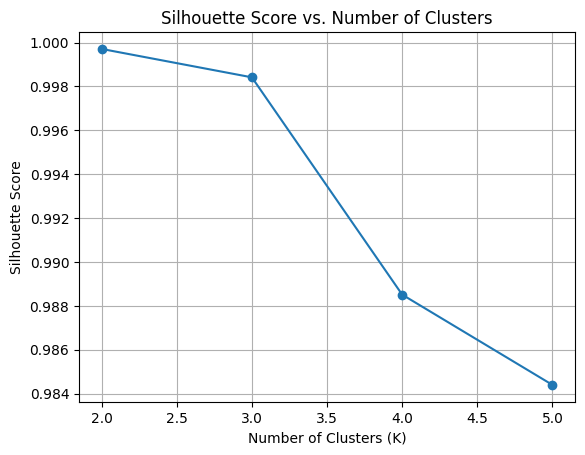

In [33]:
k_values, scores = zip(*silhouette_scores) #prep silhouette scores

# Plot

plt.plot(k_values, scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.grid(True)
plt.show()

In [37]:
# Define the K-means clustering model (once optimal found) 
#Optimal value is 4!!
#Scale appropriately
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False)
scaler_model = scaler.fit(assembled_df)
data_df = scaler_model.transform(assembled_df)

kmeans = KMeans(k=4, featuresCol="scaled_features", predictionCol="cluster")
kmeans_model = kmeans.fit(data_df)
# Assigning the data points to clusters
clustered_data = kmeans_model.transform(data_df)

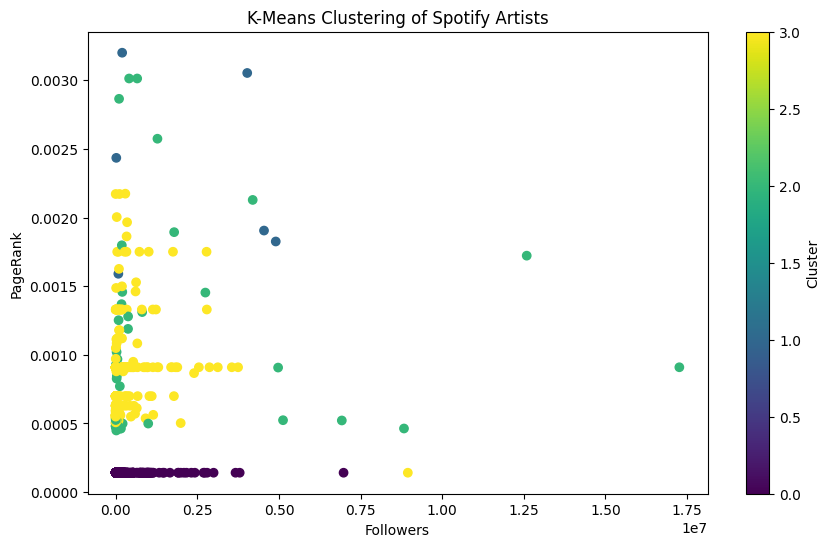

In [43]:
import pandas as pd #the only way this will work is with pandas :(
#convert to a dataframe
selected = clustered_data.select("followers", "pagerank", "cluster")
#clustered_data_df = spark.createDataframe(selected) #This throws an error
clustered_data_pd = selected.toPandas()
# Visualizing the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    clustered_data_pd["followers"],
    clustered_data_pd["pagerank"],
    c=clustered_data_pd["cluster"],
    cmap='viridis'
)
plt.xlabel("Followers")
plt.ylabel("PageRank")
plt.title("K-Means Clustering of Spotify Artists")
plt.colorbar(scatter, label="Cluster")
plt.show()

#MAYBE TRY ANOTHER GRAPH WITH DEGREE instead of PAGERANK as DEGREE was also in the top!

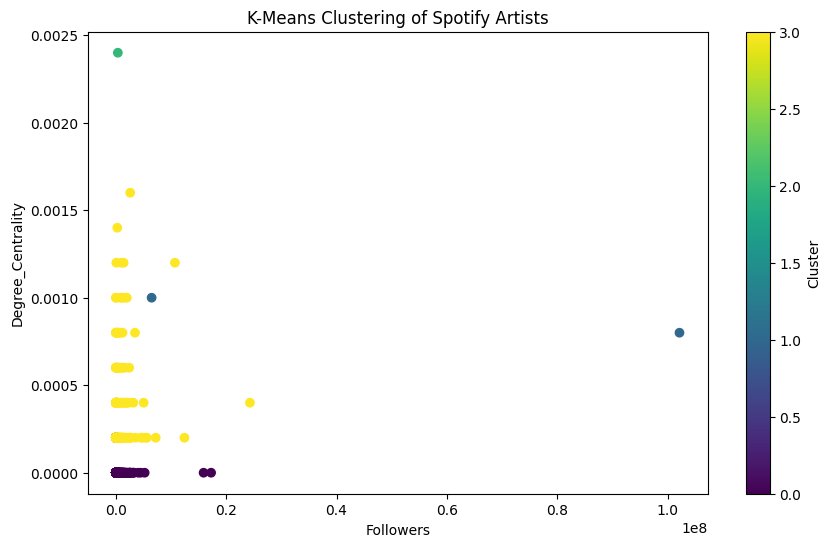

In [39]:
import pandas as pd #the only way this will work is with pandas :(
#convert to a dataframe
selected = clustered_data.select("followers", "degree_centrality", "cluster")
#clustered_data_df = spark.createDataframe(selected) #This throws an error
clustered_data_pd = selected.toPandas()
# Visualizing the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    clustered_data_pd["followers"],
    clustered_data_pd["degree_centrality"],
    c=clustered_data_pd["cluster"],
    cmap='viridis'
)
plt.xlabel("Followers")
plt.ylabel("Degree_Centrality")
plt.title("K-Means Clustering of Spotify Artists")
plt.colorbar(scatter, label="Cluster")
plt.show()


In [55]:
#cluster inspection
clusters_df.groupBy("prediction").agg(
    {"followers": "avg",
     "degree_centrality": "avg",
     "pagerank": "avg",
     "eigenvector_centrality": "avg"}
).show()


+----------+-----------------+---------------------------+----------------------+--------------------+
|prediction|   avg(followers)|avg(eigenvector_centrality)|avg(degree_centrality)|       avg(pagerank)|
+----------+-----------------+---------------------------+----------------------+--------------------+
|         1|     1.71305935E7|       7.052480068131124E-5|  5.001000200040008E-4|0.001291361470840...|
|         0|57329.61536922153|       6.550756491983733E-4|  2.189751538460574...|1.997626947120125...|
+----------+-----------------+---------------------------+----------------------+--------------------+



In [93]:
#Code to check for Nulls and NaNs because of errors
columns_to_check = ["degree_centrality", "betweenness_centrality", "closeness_centrality", 
                    "eigenvector_centrality", "pagerank", "followers"]

# Check for nulls
spark_df.select([col(c).isNull().alias(f"{c}_isNull") for c in columns_to_check]).show()

# Check for NaNs
from pyspark.sql.functions import isnan
spark_df.select([isnan(col(c)).alias(f"{c}_isNaN") for c in columns_to_check]).show()

+------------------------+-----------------------------+---------------------------+-----------------------------+---------------+----------------+
|degree_centrality_isNull|betweenness_centrality_isNull|closeness_centrality_isNull|eigenvector_centrality_isNull|pagerank_isNull|followers_isNull|
+------------------------+-----------------------------+---------------------------+-----------------------------+---------------+----------------+
|                   false|                        false|                      false|                        false|          false|           false|
|                   false|                        false|                      false|                        false|          false|           false|
|                   false|                        false|                      false|                        false|          false|           false|
|                   false|                        false|                      false|                        fals